In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

**Topology discovery plots**

Experiment 1: 
Cost and trace cost for varying GPS and encoder noise

In [12]:
df = pd.read_csv("results_topology_discovery_123.csv")
df = df[np.isfinite(df["cost_per_obs"])]  # safety filter

# Normalise by total samples per subplot cell (both classes share same denominator)
df["weight"] = 1.0 / df.groupby(["sigma_pos", "sigma_theta", "sigma_encoder", "k"])["cost_per_obs"].transform("size")

encoder_vals = sorted(df["sigma_encoder"].unique())          # columns (x-axis)
pos_theta_vals = sorted(df.groupby(["sigma_pos","sigma_theta"]).groups)  # rows (y-axis)
k_vals = sorted(df["k"].unique()) 

for k, df_k in df.groupby("k"):
    
    fig, axes = plt.subplots(
        len(pos_theta_vals), 
        len(encoder_vals),
        figsize=(4 * len(encoder_vals), 3.5 * len(pos_theta_vals)),
        sharey=False
    )
    axes = np.atleast_2d(axes)  # Safe grid indexing for 1x1 or 1xN shapes

    palette = {True: "#1f77b4", False: "#ff7f0e"}

    for r, (sp, st) in enumerate(pos_theta_vals):
        for c, se in enumerate(encoder_vals):
            ax = axes[r, c]
            
            # Fast filter on the pre-sliced df_k
            sub = df_k[
                (df_k["sigma_pos"] == sp) & 
                (df_k["sigma_theta"] == st) & 
                (df_k["sigma_encoder"] == se)
            ]

            if sub.empty:
                ax.set_visible(False)
                continue

            sns.histplot(
                data=sub, 
                x="cost_per_obs", 
                hue="connected",
                weights="weight", 
                bins=100, 
                ax=ax,
                element="step", 
                fill=True, 
                alpha=0.4,
                palette=palette, 
                legend=(r == 0 and c == 0)
            )

            if r == 0:
                ax.set_title(f"sigma_enc = {se}", fontsize=10)
            ax.set_ylabel(f"sigma_pos={sp}, sigma_θ={st}\nproportion" if c == 0 else "")
            ax.set_xlabel("cost_per_obs" if r == len(pos_theta_vals) - 1 else "")

    # Include k in title and filename
    fig.suptitle(f"cost_per_obs distribution — k = {k} (connected vs not connected)", y=1.01)
    plt.tight_layout()
    plt.savefig(f"topology_cost_grid_k_{k}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)  # Prevents memory accumulation when generating multiple figures

In [ ]:
# 1. Filter and get top 10 per group
result = (
    df[df["connected"] == False]
    .sort_values("cost_per_obs")
    .groupby(["sigma_pos", "sigma_theta", "sigma_encoder"], as_index=False)
    .head(10)
)

# 2. Iterate and print
cols = ["sigma_pos", "sigma_theta", "sigma_encoder", "limb_id", "child_id", "cost_per_obs"]

for group_key, group_df in result.groupby(["sigma_pos", "sigma_theta", "sigma_encoder"]):
    print(f"\n=== Group Key: {group_key} ===")
    print(group_df[cols].to_string(index=False))

**Calibration**

Experiment 1: how calibration accuracy varies with range and encoder noise

In [37]:
df = pd.read_csv("results_calibration_1.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Clean out non-finite values if any exist
df = df[np.isfinite(df["euclidean_error"])]

# Extract unique window sizes to iterate over
window_sizes = sorted(df["window_size"].unique())

# 3. Generate a plot for each window_size
for ws, df_ws in df.groupby("window_size"):
    
    # Aggregate data into a 2D Pivot Table (Mean Euclidean Error per cell)
    # Rows: sigma_encoder (y-axis), Columns: sigma_range (x-axis)
    pivot_error = df_ws.pivot_table(
        index="sigma_encoder", 
        columns="sigma_range", 
        values="euclidean_error", 
        aggfunc="mean"  # Change to "median" if you have extreme outlier runs
    )

    # Sort index descending so larger sigma_encoder values appear at top of y-axis
    pivot_error = pivot_error.sort_index(ascending=False)

    # Plot Setup
    fig, ax = plt.subplots(figsize=(8, 6))

    # Seaborn Heatmap for 2D Grid Visualization
    sns.heatmap(
        pivot_error, 
        annot=True,          # Displays numerical error values inside cells
        fmt=".3f",           # Formats numbers to 3 decimal places
        # cmap="Viridis_r",    # Reversed scale so lower error = brighter/better
        cbar_kws={'label': 'Mean Euclidean Error'},
        ax=ax
    )

    # Axis Labels & Titles
    ax.set_title(f"Euclidean Error Grid — window_size = {ws}", fontsize=12, pad=12)
    ax.set_xlabel("sigma_range", fontsize=10)
    ax.set_ylabel("sigma_encoder", fontsize=10)

    plt.tight_layout()
    plt.savefig(f"euclidean_error_grid_ws_{ws}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)  # Close figure to free up RAM

In [36]:
df = pd.read_csv("results_calibration_1.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Clean out non-finite values if any exist
df = df[np.isfinite(df["euclidean_error"])]

encoder_vals = sorted(df["sigma_encoder"].unique())  # Rows (y-axis)
range_vals = sorted(df["sigma_range"].unique())      # Columns (x-axis)

for ws, df_ws in df.groupby("window_size"):
    
    fig, axes = plt.subplots(
        len(encoder_vals), 
        len(range_vals),
        figsize=(3.5 * len(range_vals), 3.0 * len(encoder_vals)),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_2d(axes)

    for r, se in enumerate(reversed(encoder_vals)):  # Higher encoder on top
        for c, sr in enumerate(range_vals):
            ax = axes[r, c]
            
            sub = df_ws[(df_ws["sigma_encoder"] == se) & (df_ws["sigma_range"] == sr)]

            if sub.empty:
                ax.set_visible(False)
                continue

            sns.histplot(
                data=sub, 
                x="euclidean_error", 
                bins=30, 
                ax=ax,
                color="#1f77b4",
                element="step", 
                fill=True, 
                alpha=0.5
            )

            if r == 0:
                ax.set_title(f"σ_range = {sr}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"σ_enc = {se}\nCount", fontsize=9)
            if r == len(encoder_vals) - 1:
                ax.set_xlabel("Euclidean Error", fontsize=9)

    fig.suptitle(f"Euclidean Error Distribution Grid — window_size = {ws}", y=1.02)
    plt.tight_layout()
    plt.savefig(f"error_hist_grid_ws_{ws}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

In [35]:
df = pd.read_csv("results_calibration_1.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter invalid values
df = df[np.isfinite(df["euclidean_error"])]

# Unique parameter values
range_vals = sorted(df["sigma_range"].unique())     # Grid X-axis (columns)
encoder_vals = sorted(df["sigma_encoder"].unique()) # Grid Y-axis (rows)
window_sizes = sorted(df["window_size"].unique())

# 3. Generate Grid Plot for each window_size
for ws, df_ws in df.groupby("window_size"):

    fig, axes = plt.subplots(
        len(encoder_vals),
        len(range_vals),
        figsize=(3.5 * len(range_vals), 3.0 * len(encoder_vals)),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_2d(axes)

    # Plot higher encoder values at top of grid
    for r, se in enumerate(reversed(encoder_vals)):
        for c, sr in enumerate(range_vals):
            ax = axes[r, c]

            # Filter raw dataset for this grid cell
            sub = df_ws[
                (df_ws["sigma_encoder"] == se) & 
                (df_ws["sigma_range"] == sr)
            ]

            if sub.empty:
                ax.set_visible(False)
                continue

            # Seaborn barplot automatically calculates Mean + Error Bars
            # errorbar="sd" plots Standard Deviation. 
            # Set errorbar="ci" (or 95) for 95% Confidence Interval.
            sns.barplot(
                data=sub,
                x="calib_id",
                y="euclidean_error",
                ax=ax,
                color="#1f77b4",
                alpha=0.85,
                errorbar="sd",       # Options: "sd" (Standard Dev) or ("ci", 95)
                capsize=0.15,        # Adds horizontal caps to the error bars
                err_kws={'linewidth': 1.2, 'color': 'black'}
            )

            # Titles & Axis Labels
            if r == 0:
                ax.set_title(f"σ_range = {sr}", fontsize=10)
            if c == 0:
                ax.set_ylabel(f"σ_enc = {se}\nMean Error", fontsize=9)
            else:
                ax.set_ylabel("")

            if r == len(encoder_vals) - 1:
                ax.set_xlabel("Calibration ID", fontsize=9)
            else:
                ax.set_xlabel("")

            # Rotate ID tick labels for readability
            ax.tick_params(axis='x', rotation=45)

    fig.suptitle(f"Mean Euclidean Error with Error Bars (±1 SD) — window_size = {ws}", y=1.02, fontsize=12)
    plt.tight_layout()
    plt.savefig(f"error_by_id_grid_ws_{ws}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

Experiment 2: number of limbs and solver iterations needed. calibration accuracy

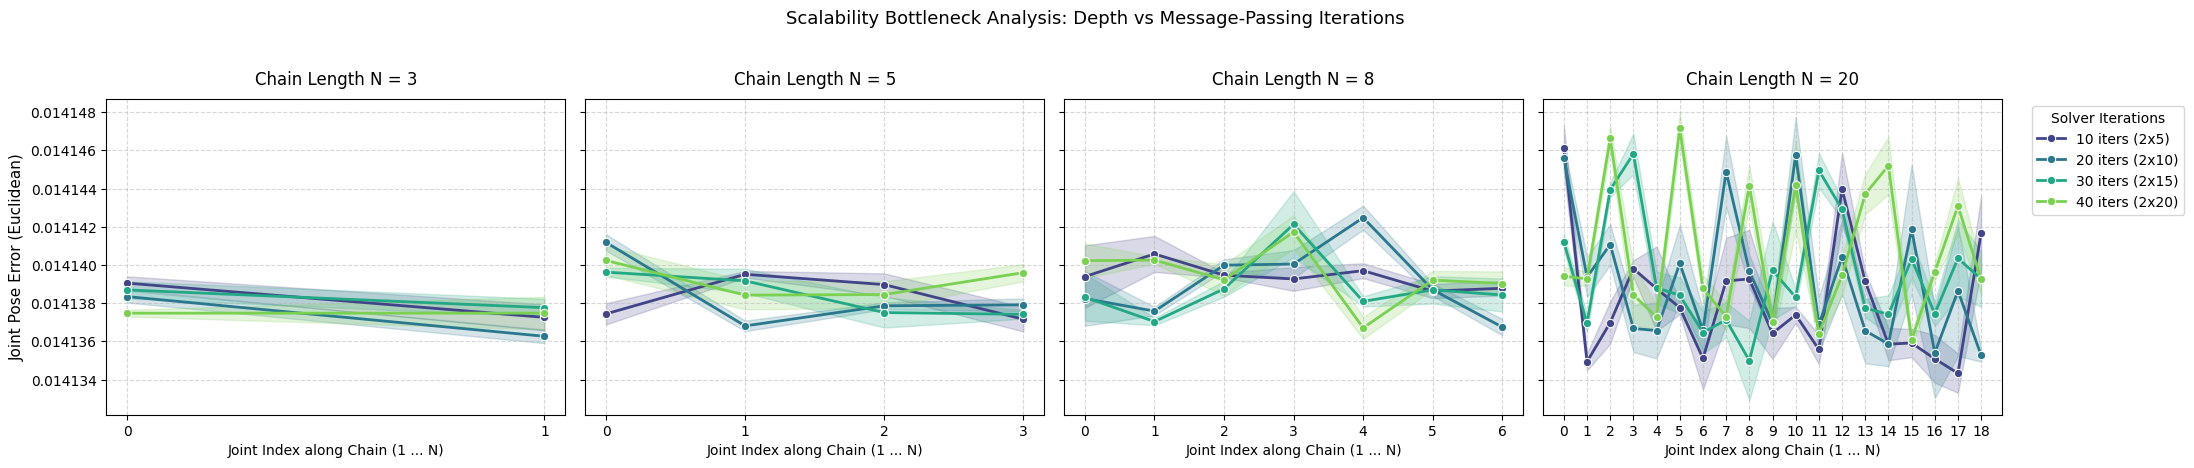

In [50]:
import glob

# 1. Define list of dataset files or load via glob pattern
# Example list of files: ["dataset_N3.csv", "dataset_N6.csv", "dataset_N12.csv"]
dataset_files = glob.glob("results_calibration_2_*.csv")

dataframes = []

for file in dataset_files:
    temp_df = pd.read_csv(file)
    
    # Extract chain length N from file name or a dedicated column if available
    # Assuming 'n_limbs' column exists; if not, parse it or assign explicitly
    if "n_limbs" not in temp_df.columns:
        # Fallback: estimate N as max calib_id + 1 for this file
        temp_df["n_limbs"] = temp_df["calib_id"].max() + 1
        
    dataframes.append(temp_df)

# Combine into a single unified DataFrame
df = pd.concat(dataframes, ignore_index=True)

# 2. Compute Euclidean Joint Position Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter out non-finite values
df = df[np.isfinite(df["euclidean_error"])].copy()

# 3. Compute Total Iterations (I = n_outer * n_inner)
# Creates a clean label for legend sorting
df["total_iterations"] = df["n_outer"] * df["n_inner"]
df["iteration_label"] = df["total_iterations"].astype(str) + " iters (" + \
                        df["n_outer"].astype(str) + "x" + df["n_inner"].astype(str) + ")"

# Sort unique N and iterations for consistent plotting
chain_lengths = sorted(df["n_limbs"].unique())
iter_orders = (
    df[["total_iterations", "iteration_label"]]
    .drop_duplicates()
    .sort_values("total_iterations")["iteration_label"]
    .tolist()
)

# 4. Setup Faceted Subplot Grid (1 row, Facet by Chain Length N)
fig, axes = plt.subplots(
    nrows=1, 
    ncols=len(chain_lengths), 
    figsize=(5.5 * len(chain_lengths), 4.5), 
    sharey=True
)

if len(chain_lengths) == 1:
    axes = [axes]

palette = sns.color_palette("viridis", n_colors=len(iter_orders))

# 5. Plot Line Series per Chain Length (N)
for idx, n_val in enumerate(chain_lengths):
    ax = axes[idx]
    sub_df = df[df["n_limbs"] == n_val]
    
    # Lineplot automatically averages over repeated runs and adds shaded CIs (±1 SD)
    sns.lineplot(
        data=sub_df,
        x="calib_id",
        y="euclidean_error",
        hue="iteration_label",
        hue_order=iter_orders,
        marker="o",
        linewidth=2,
        palette=palette,
        errorbar="sd",
        ax=ax
    )
    
    # Formatting
    ax.set_title(f"Chain Length N = {n_val}", fontsize=12, pad=10)
    ax.set_xlabel("Joint Index along Chain (1 ... N)", fontsize=10)
    ax.set_xticks(sorted(sub_df["calib_id"].unique()))
    ax.grid(True, linestyle="--", alpha=0.5)
    
    if idx == 0:
        ax.set_ylabel("Joint Pose Error (Euclidean)", fontsize=11)
    else:
        ax.set_ylabel("")
        
    # Manage legends across subplots (only keep on rightmost plot)
    if idx == len(chain_lengths) - 1:
        ax.legend(title="Solver Iterations", bbox_to_anchor=(1.05, 1), loc='upper left')
    else:
        ax.get_legend().remove()

fig.suptitle("Scalability Bottleneck Analysis: Depth vs Message-Passing Iterations", y=1.03, fontsize=13)
plt.tight_layout()
plt.savefig("scalability_chain_length_vs_iterations.png", dpi=150, bbox_inches="tight")
plt.show()

Experiment 3: how calibration accuracy varies with movement type

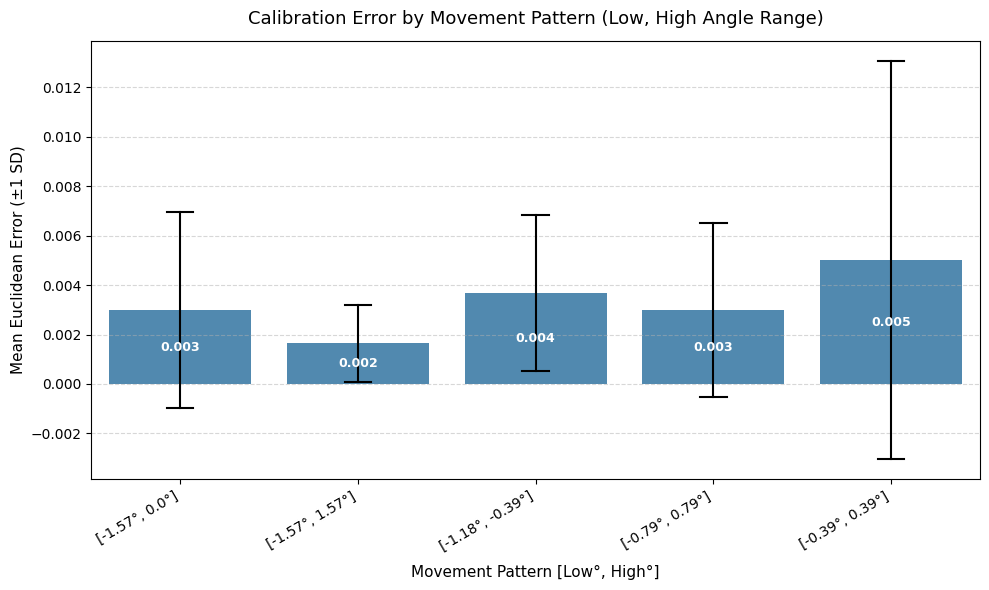

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load dataset
df = pd.read_csv("results_calibration_3.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter out invalid values
df = df[np.isfinite(df["euclidean_error"])].copy()

# 3. Combine movement_low and movement_high into a single readable label
df["movement_pattern"] = (
    "[" + df["movement_low"].round(2).astype(str) + "°, " + df["movement_high"].round(2).astype(str) + "°]"
)

# Sort patterns logically by low angle then high angle
pattern_order = (
    df[["movement_low", "movement_high", "movement_pattern"]]
    .drop_duplicates()
    .sort_values(by=["movement_low", "movement_high"])["movement_pattern"]
    .tolist()
)

# 4. Plot Setup
fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=df,
    x="movement_pattern",
    y="euclidean_error",
    order=pattern_order,
    ax=ax,
    color="#1f77b4",
    alpha=0.85,
    errorbar="sd",       # Displays ±1 Standard Deviation
    capsize=0.15,        # Adds horizontal caps to error bars
    err_kws={'linewidth': 1.5, 'color': 'black'}
)

# Add data labels (exact mean values) on top of each bar for quick scanning
mean_vals = df.groupby("movement_pattern", observed=False)["euclidean_error"].mean()
for i, pattern in enumerate(pattern_order):
    if pattern in mean_vals:
        val = mean_vals[pattern]
        ax.text(
            i, val * 0.5, f"{val:.3f}", 
            ha='center', va='center', color='white', fontweight='bold', fontsize=9
        )

# Axis Labels and Styling
ax.set_title("Calibration Error by Movement Pattern (Low, High Angle Range)", fontsize=13, pad=12)
ax.set_xlabel("Movement Pattern [Low°, High°]", fontsize=11, labelpad=8)
ax.set_ylabel("Mean Euclidean Error (±1 SD)", fontsize=11)
ax.grid(axis="y", linestyle="--", alpha=0.5)

plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("calibration_error_by_movement_pattern.png", dpi=150, bbox_inches="tight")
plt.show()

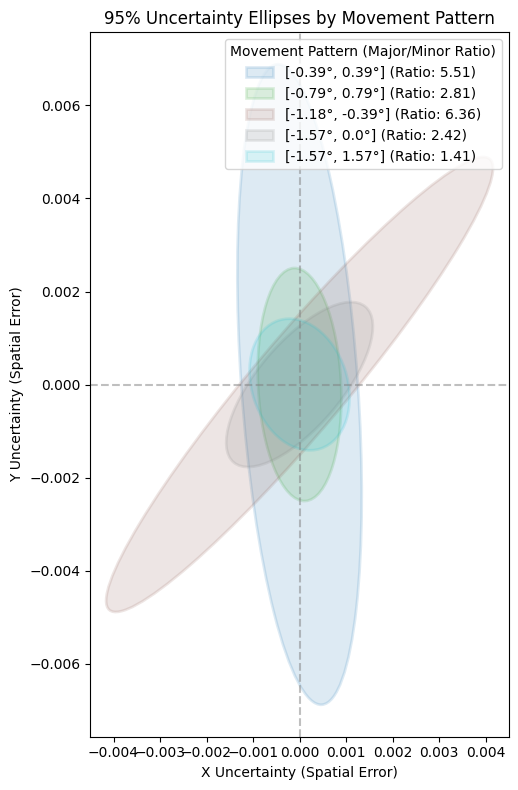

In [45]:
from matplotlib.patches import Ellipse

# Example function to calculate 95% confidence ellipse parameters from 2x2 Covariance Matrix
def get_ellipse_params(cov, n_std=2.447):  # 2.447 scale factor for 95% CI in 2D
    # Eigen decomposition
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort eigenvalues & eigenvectors descending
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Calculate angle of primary eigenvector in degrees
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

    # Width and Height are diameters (2 * std * scale)
    width = 2 * n_std * np.sqrt(np.maximum(0, eigenvalues[0]))
    height = 2 * n_std * np.sqrt(np.maximum(0, eigenvalues[1]))

    return width, height, angle, eigenvalues


# 1. Load dataset
df = pd.read_csv("results_calibration_3.csv")

# 2. Compute Euclidean Distance Error
df["euclidean_error"] = np.sqrt(
    (df["est_cj_x"] - df["cj_x"]) ** 2 + 
    (df["est_cj_y"] - df["cj_y"]) ** 2
)

# Filter out invalid values
df = df[np.isfinite(df["euclidean_error"])].copy()

# 3. Combine movement_low and movement_high into a single readable label
df["movement_pattern"] = (
    "[" + df["movement_low"].round(2).astype(str) + "°, " + df["movement_high"].round(2).astype(str) + "°]"
)

# --- Assuming df has columns: 'movement_pattern', 'cov_00', 'cov_01', 'cov_10', 'cov_11' ---
# If you have multiple runs per pattern, average the covariance matrices first:
avg_covs = df.groupby("movement_pattern")[["cov_00", "cov_01", "cov_10", "cov_11"]].mean()

fig, ax = plt.subplots(figsize=(8, 8))

# Color palette for patterns
patterns = avg_covs.index
colors = plt.cm.tab10(np.linspace(0, 1, len(patterns)))

for i, pattern in enumerate(patterns):
    row = avg_covs.loc[pattern]
    cov = np.array([[row["cov_00"], row["cov_01"]], 
                    [row["cov_10"], row["cov_11"]]])
    
    width, height, angle, (lam1, lam2) = get_ellipse_params(cov)

    # Draw 95% Error Ellipse centered at origin (0,0)
    ellipse = Ellipse(
        xy=(0, 0), width=width, height=height, angle=angle,
        edgecolor=colors[i], facecolor=colors[i], alpha=0.15, lw=2,
        label=f"{pattern} (Ratio: {np.sqrt(lam1/lam2):.2f})"
    )
    ax.add_patch(ellipse)
    
    # Optional: Draw major eigenvector axis arrow
    # rad = np.radians(angle)
    # ax.arrow(0, 0, (width/2)*np.cos(rad), (width/2)*np.sin(rad),
    #          color=colors[i], head_width=0.005, length_includes_head=True)

# Plot Formatting
ax.set_aspect('equal')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title("95% Uncertainty Ellipses by Movement Pattern", fontsize=12)
ax.set_xlabel("X Uncertainty (Spatial Error)", fontsize=10)
ax.set_ylabel("Y Uncertainty (Spatial Error)", fontsize=10)
ax.legend(title="Movement Pattern (Major/Minor Ratio)", loc="upper right")
ax.autoscale()

plt.tight_layout()
plt.savefig("uncertainty_ellipses_by_pattern.png", dpi=150)
plt.show()